<a href="https://colab.research.google.com/github/Pushkarsinghs/indian_stock-analysis/blob/pages/07_Backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Indian Stock Market Analysis
## Notebook 7: Strategy Backtester

Tests whether the Signal_Score system from Notebook 2 actually
generates returns better than simply holding NIFTY 50.

**Method:** Simulate buying on Strong Buy/Buy signals, selling
on Strong Sell/Sell signals, compare cumulative returns against
an equal-weight buy-and-hold benchmark.

**Output:** Strategy vs benchmark equity curve + performance
metrics table for Power BI

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pyarrow -q

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

BASE = '/content/drive/MyDrive/indian_stock_analysis'

tech_df = pd.read_parquet(f"{BASE}/data/processed/nifty50_technical.parquet")
tech_df["Date"] = pd.to_datetime(tech_df["Date"])
if tech_df["Date"].dt.tz is not None:
    tech_df["Date"] = tech_df["Date"].dt.tz_localize(None)

print(f"✅ Loaded {tech_df.shape[0]:,} rows across {tech_df['Ticker'].nunique()} stocks")
print(f"📅 {tech_df['Date'].min().date()} → {tech_df['Date'].max().date()}")

Mounted at /content/drive
✅ Loaded 12,236 rows across 49 stocks
📅 2025-07-08 → 2026-07-08


In [ ]:
def backtest_signal_strategy(df, ticker, initial_capital=100000):
    """
    Simulates a simple signal-following strategy:
    - Enter (go long) when Signal is Strong Buy or Buy
    - Exit (go to cash) when Signal is Strong Sell or Sell
    - Stay in current position on Neutral/Weak signals
    """
    stock = df[df["Ticker"] == ticker].copy().sort_values("Date")
    stock = stock.dropna(subset=["Close", "Signal"]).reset_index(drop=True)

    if len(stock) < 30:
        return None

    position   = 0          # 0 = cash, 1 = holding stock
    cash       = initial_capital
    shares     = 0
    equity_curve = []
    trade_log  = []

    for i, row in stock.iterrows():
        price  = row["Close"]
        signal = row["Signal"]
        date   = row["Date"]

        # Entry logic
        if position == 0 and signal in ["Strong Buy", "Buy"]:
            shares   = cash / price
            cash     = 0
            position = 1
            trade_log.append({
                "Date": date, "Action": "BUY",
                "Price": round(price, 2), "Signal": signal
            })

        # Exit logic
        elif position == 1 and signal in ["Strong Sell", "Sell"]:
            cash     = shares * price
            shares   = 0
            position = 0
            trade_log.append({
                "Date": date, "Action": "SELL",
                "Price": round(price, 2), "Signal": signal
            })

        # Mark-to-market equity for this day
        current_equity = cash + (shares * price)
        equity_curve.append({
            "Date": date,
            "Ticker": ticker,
            "Strategy_Equity": round(current_equity, 2),
            "Close": price
        })

    equity_df = pd.DataFrame(equity_curve)
    trades_df = pd.DataFrame(trade_log)

    # Buy-and-hold benchmark for the same stock
    bh_shares = initial_capital / stock["Close"].iloc[0]
    equity_df["BuyHold_Equity"] = round(bh_shares * equity_df["Close"], 2)

    return equity_df, trades_df


print("✅ Backtest engine ready!")

✅ Backtest engine ready!


In [ ]:
all_equity  = []
all_trades  = []
summary_rows = []

tickers = tech_df["Ticker"].unique()
print(f"🔄 Backtesting {len(tickers)} stocks...\n")

for i, ticker in enumerate(tickers, 1):
    result = backtest_signal_strategy(tech_df, ticker)
    if result is None:
        print(f"  ⚠️  [{i:02d}] {ticker} — insufficient data")
        continue

    equity_df, trades_df = result
    all_equity.append(equity_df)

    if not trades_df.empty:
        trades_df["Ticker"] = ticker
        all_trades.append(trades_df)

    # Performance summary
    strategy_final = equity_df["Strategy_Equity"].iloc[-1]
    benchmark_final = equity_df["BuyHold_Equity"].iloc[-1]
    strategy_return  = round((strategy_final / 100000 - 1) * 100, 2)
    benchmark_return = round((benchmark_final / 100000 - 1) * 100, 2)
    outperformance    = round(strategy_return - benchmark_return, 2)
    num_trades        = len(trades_df) if not trades_df.empty else 0

    summary_rows.append({
        "Ticker":            ticker,
        "Strategy_Return_Pct":  strategy_return,
        "BuyHold_Return_Pct":   benchmark_return,
        "Outperformance_Pct":   outperformance,
        "Num_Trades":           num_trades,
        "Beat_Benchmark":       "Yes" if outperformance > 0 else "No"
    })

    marker = "✅" if outperformance > 0 else "➖"
    print(f"  {marker} [{i:02d}/{len(tickers)}] {ticker:<18} "
          f"Strategy: {strategy_return:>+7.2f}%  "
          f"BuyHold: {benchmark_return:>+7.2f}%  "
          f"Trades: {num_trades}")

equity_all_df  = pd.concat(all_equity, ignore_index=True)
trades_all_df  = pd.concat(all_trades, ignore_index=True) if all_trades else pd.DataFrame()
summary_df     = pd.DataFrame(summary_rows).sort_values(
    "Outperformance_Pct", ascending=False
)

print(f"\n✅ Backtest complete!")

🔄 Backtesting 49 stocks...

  ✅ [01/49] ADANIENT.NS        Strategy:  +33.60%  BuyHold:  +20.17%  Trades: 7
  ➖ [02/49] ADANIPORTS.NS      Strategy:  +26.64%  BuyHold:  +27.74%  Trades: 5
  ➖ [03/49] APOLLOHOSP.NS      Strategy:  +12.71%  BuyHold:  +17.42%  Trades: 7
  ✅ [04/49] ASIANPAINT.NS      Strategy:  +33.31%  BuyHold:   +9.73%  Trades: 9
  ➖ [05/49] AXISBANK.NS        Strategy:  +10.86%  BuyHold:  +14.24%  Trades: 9
  ➖ [06/49] BAJAJ-AUTO.NS      Strategy:  +12.08%  BuyHold:  +23.59%  Trades: 7
  ✅ [07/49] BAJAJFINSV.NS      Strategy:   -2.48%  BuyHold:   -6.47%  Trades: 12
  ✅ [08/49] BAJFINANCE.NS      Strategy:  +12.40%  BuyHold:  +11.69%  Trades: 11
  ✅ [09/49] BHARTIARTL.NS      Strategy:   +7.78%  BuyHold:   -4.63%  Trades: 4
  ✅ [10/49] BPCL.NS            Strategy:  +18.26%  BuyHold:   -8.86%  Trades: 6
  ✅ [11/49] BRITANNIA.NS       Strategy:   -4.67%  BuyHold:   -5.91%  Trades: 12
  ✅ [12/49] CIPLA.NS           Strategy:   +6.59%  BuyHold:   -0.93%  Trades: 7
  ➖ [13/4

In [ ]:
win_rate = round((summary_df["Beat_Benchmark"] == "Yes").mean() * 100, 1)
avg_strategy  = round(summary_df["Strategy_Return_Pct"].mean(), 2)
avg_benchmark = round(summary_df["BuyHold_Return_Pct"].mean(), 2)

print("=" * 60)
print("  📊 STRATEGY VS BUY-AND-HOLD — OVERALL RESULTS")
print("=" * 60)
print(f"  Stocks where strategy beat buy-and-hold: {win_rate}%")
print(f"  Average strategy return:                 {avg_strategy:+.2f}%")
print(f"  Average buy-and-hold return:              {avg_benchmark:+.2f}%")
print(f"  Average outperformance:                   {avg_strategy - avg_benchmark:+.2f}%")
print("=" * 60)

print("\n🏆 Top 10 stocks where signal strategy worked best:")
print(summary_df.head(10).to_string(index=False))

print("\n⚠️  Bottom 10 — signal strategy underperformed:")
print(summary_df.tail(10).to_string(index=False))

  📊 STRATEGY VS BUY-AND-HOLD — OVERALL RESULTS
  Stocks where strategy beat buy-and-hold: 40.8%
  Average strategy return:                 +2.08%
  Average buy-and-hold return:              +4.67%
  Average outperformance:                   -2.59%

🏆 Top 10 stocks where signal strategy worked best:
       Ticker  Strategy_Return_Pct  BuyHold_Return_Pct  Outperformance_Pct  Num_Trades Beat_Benchmark
     WIPRO.NS                -3.32              -32.18               28.86           8            Yes
       TCS.NS                -8.09              -36.28               28.19          10            Yes
      BPCL.NS                18.26               -8.86               27.12           6            Yes
ASIANPAINT.NS                33.31                9.73               23.58           9            Yes
   HCLTECH.NS                -5.54              -28.97               23.43           8            Yes
      INFY.NS               -14.15              -32.26               18.11          10  

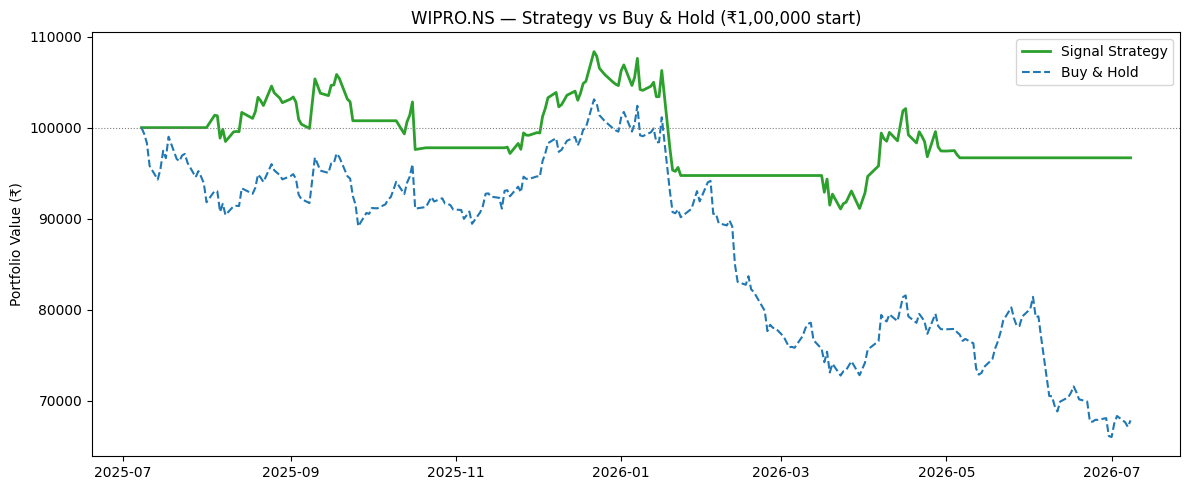

✅ Best performer chart saved: WIPRO.NS


In [ ]:
import matplotlib.pyplot as plt

def plot_backtest(equity_df, ticker):
    stock_eq = equity_df[equity_df["Ticker"] == ticker]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(stock_eq["Date"], stock_eq["Strategy_Equity"],
            label="Signal Strategy", color="#2CA02C", lw=2)
    ax.plot(stock_eq["Date"], stock_eq["BuyHold_Equity"],
            label="Buy & Hold", color="#1F77B4", lw=1.5, ls="--")
    ax.axhline(100000, color="gray", lw=0.8, ls=":")
    ax.set_title(f"{ticker} — Strategy vs Buy & Hold (₹1,00,000 start)")
    ax.set_ylabel("Portfolio Value (₹)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{BASE}/data/output/07_backtest_{ticker.replace('.NS','')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

# Plot the best performer and a middle performer
best_ticker = summary_df.iloc[0]["Ticker"]
plot_backtest(equity_all_df, best_ticker)
print(f"✅ Best performer chart saved: {best_ticker}")

In [ ]:
# Full daily equity curves (for the main backtest chart)
equity_all_df.to_parquet(f"{BASE}/data/processed/backtest_equity.parquet", index=False)
equity_all_df.to_csv(f"{BASE}/data/output/backtest_equity_powerbi.csv", index=False)

# Trade log (for a trade-by-trade table)
if not trades_all_df.empty:
    trades_all_df.to_csv(f"{BASE}/data/output/backtest_trades_powerbi.csv", index=False)

# Summary table (for the main comparison bar chart)
summary_df.to_csv(f"{BASE}/data/output/backtest_summary_powerbi.csv", index=False)

print("✅ backtest_equity_powerbi.csv saved")
print("✅ backtest_trades_powerbi.csv saved")
print("✅ backtest_summary_powerbi.csv saved")
print(f"\n📊 {summary_df.shape[0]} stocks backtested")
print(f"📈 {len(trades_all_df) if not trades_all_df.empty else 0} total trades executed")

✅ backtest_equity_powerbi.csv saved
✅ backtest_trades_powerbi.csv saved
✅ backtest_summary_powerbi.csv saved

📊 49 stocks backtested
📈 401 total trades executed
